In [275]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [276]:
df_scaled = pd.read_csv("feature_engineering.csv")

In [277]:
df_scaled.drop(columns=["Payment_Method", "Age_Group"], inplace=True)

In [278]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 2, random_state = 42)
kmeans.fit(df_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [279]:
df_scaled

,Age,Gender,Unit_Price,Quantity,Is_Returning_Customer,Delivery_Time_Days,Year,Month,Day,DayOfWeek,...,Gender_Payment_Male_Cash on Delivery,Gender_Payment_Male_Credit Card,Gender_Payment_Male_Debit Card,Gender_Payment_Male_Digital Wallet,Gender_Payment_Other_Bank Transfer,Gender_Payment_Other_Cash on Delivery,Gender_Payment_Other_Credit Card,Gender_Payment_Other_Debit Card,Gender_Payment_Other_Digital Wallet,Age_x_Gender
0,27,0,54.28,1,True,8,2023,1,1,6,...,False,False,False,False,False,False,False,False,False,0
1,42,1,244.90,1,True,3,2023,1,1,6,...,False,True,False,False,False,False,False,False,False,42
2,43,0,48.15,5,True,5,2023,1,1,6,...,False,False,False,False,False,False,False,False,False,0
3,32,1,804.06,1,False,1,2023,1,1,6,...,False,True,False,False,False,False,False,False,False,32
4,40,0,755.61,5,True,7,2023,1,1,6,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,0,130.35,1,False,9,2024,3,26,1,...,False,False,False,False,False,False,False,False,False,0
4996,27,1,71.55,1,True,6,2024,3,26,1,...,False,False,True,False,False,False,False,False,False,27
4997,45,0,39.38,1,True,5,2024,3,26,1,...,False,False,False,False,False,False,False,False,False,0
4998,41,0,171.19,1,True,5,2024,3,26,1,...,False,False,False,False,False,False,False,False,False,0


In [280]:
df_scaled['cluster'] = kmeans.labels_

In [281]:
cluster1 = df_scaled[df_scaled['cluster'] == 0]
cluster2 = df_scaled[df_scaled['cluster'] == 1]
'''
cluster3 = df_scaled[df_scaled['cluster'] == 2]
cluster4 = df_scaled[df_scaled['cluster'] == 3]
cluster5 = df_scaled[df_scaled['cluster'] == 4]
cluster6 = df_scaled[df_scaled['cluster'] == 5]
cluster7 = df_scaled[df_scaled['cluster'] == 6]
cluster8 = df_scaled[df_scaled['cluster'] == 7]
cluster9 = df_scaled[df_scaled['cluster'] == 8]
cluster10 = df_scaled[df_scaled['cluster'] == 9]
cluster11 = df_scaled[df_scaled['cluster'] == 10]
cluster12 = df_scaled[df_scaled['cluster'] == 11]
cluster13 = df_scaled[df_scaled['cluster'] == 12]
cluster14 = df_scaled[df_scaled['cluster'] == 13]
cluster15 = df_scaled[df_scaled['cluster'] == 14]
cluster16 = df_scaled[df_scaled['cluster'] == 15]
cluster17 = df_scaled[df_scaled['cluster'] == 16]
cluster18 = df_scaled[df_scaled['cluster'] == 17]
'''

"\ncluster3 = df_scaled[df_scaled['cluster'] == 2]\ncluster4 = df_scaled[df_scaled['cluster'] == 3]\ncluster5 = df_scaled[df_scaled['cluster'] == 4]\ncluster6 = df_scaled[df_scaled['cluster'] == 5]\ncluster7 = df_scaled[df_scaled['cluster'] == 6]\ncluster8 = df_scaled[df_scaled['cluster'] == 7]\ncluster9 = df_scaled[df_scaled['cluster'] == 8]\ncluster10 = df_scaled[df_scaled['cluster'] == 9]\ncluster11 = df_scaled[df_scaled['cluster'] == 10]\ncluster12 = df_scaled[df_scaled['cluster'] == 11]\ncluster13 = df_scaled[df_scaled['cluster'] == 12]\ncluster14 = df_scaled[df_scaled['cluster'] == 13]\ncluster15 = df_scaled[df_scaled['cluster'] == 14]\ncluster16 = df_scaled[df_scaled['cluster'] == 15]\ncluster17 = df_scaled[df_scaled['cluster'] == 16]\ncluster18 = df_scaled[df_scaled['cluster'] == 17]\n"

In [282]:
cluster1.shape, cluster2.shape, #cluster3.shape, cluster4.shape, cluster5.shape, cluster6.shape, cluster7.shape, cluster9.shape, cluster10.shape, cluster11.shape, cluster12.shape, cluster13.shape, cluster14.shape, cluster15.shape, cluster16.shape, cluster17.shape, cluster18.shape

((255, 80), (4745, 80))

In [283]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def analyze_kmeans_clusters(X, labels, model=None, visualize=True, method='pca'):
    """
    Analyze the quality of KMeans clusters using multiple metrics.

    Parameters:
        X (array-like): The dataset used for clustering.
        labels (array-like): Cluster labels predicted by the model.
        model (KMeans): Trained KMeans model (optional, required for inertia).
        visualize (bool): Whether to visualize clusters in 2D.
        method (str): 'pca' or 'tsne' for dimensionality reduction.

    Returns:
        dict: A dictionary with evaluation metrics and interpretation.
    """
    results = {}

    # Silhouette Score
    sil_score = silhouette_score(X, labels)
    results['silhouette_score'] = sil_score
    print(f"Silhouette Score: {sil_score:.4f} — ", end='')
    if sil_score > 0.7:
        print("Strong structure (well-separated clusters).")
    elif sil_score > 0.5:
        print("Reasonable structure.")
    elif sil_score > 0.25:
        print("Weak structure.")
    else:
        print("No substantial structure (overlapping clusters).")

    # Calinski-Harabasz Index
    ch_score = calinski_harabasz_score(X, labels)
    results['calinski_harabasz_score'] = ch_score
    print(f"Calinski-Harabasz Index: {ch_score:.2f} — Higher is better (better-defined clusters).")

    # Davies-Bouldin Index
    db_score = davies_bouldin_score(X, labels)
    results['davies_bouldin_score'] = db_score
    print(f"Davies-Bouldin Index: {db_score:.4f} — Lower is better (less intra-cluster similarity).")

    # Inertia (if model provided)
    if model is not None and hasattr(model, 'inertia_'):
        inertia = model.inertia_
        results['inertia'] = inertia
        print(f"Inertia: {inertia:.2f} — Total within-cluster sum of squares (lower is tighter).")

    # Cluster size balance
    unique, counts = np.unique(labels, return_counts=True)
    cluster_sizes = dict(zip(unique, counts))
    size_variance = np.var(counts)
    results['cluster_sizes'] = cluster_sizes
    results['size_variance'] = size_variance
    print("Cluster sizes:", cluster_sizes)
    print(f"Size variance: {size_variance:.2f} — Low variance indicates balanced clusters.")

    # Optional 2D Visualization
    if visualize:
        if method == 'tsne':
            reducer = TSNE(n_components=2, perplexity=30, random_state=42)
        else:
            reducer = PCA(n_components=2)
        X_2d = reducer.fit_transform(X)
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', alpha=0.6)
        plt.title(f'Cluster visualization using {method.upper()}')
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
        plt.colorbar(scatter, label='Cluster Label')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return results

In [284]:
kmeans = KMeans(n_clusters = 2, random_state = 42)
labels = kmeans.fit_predict(df_scaled)

Silhouette Score: 0.8416 — Strong structure (well-separated clusters).
Calinski-Harabasz Index: 7996.24 — Higher is better (better-defined clusters).
Davies-Bouldin Index: 0.5244 — Lower is better (less intra-cluster similarity).
Inertia: 14865029383.43 — Total within-cluster sum of squares (lower is tighter).
Cluster sizes: {np.int32(0): np.int64(255), np.int32(1): np.int64(4745)}
Size variance: 5040025.00 — Low variance indicates balanced clusters.


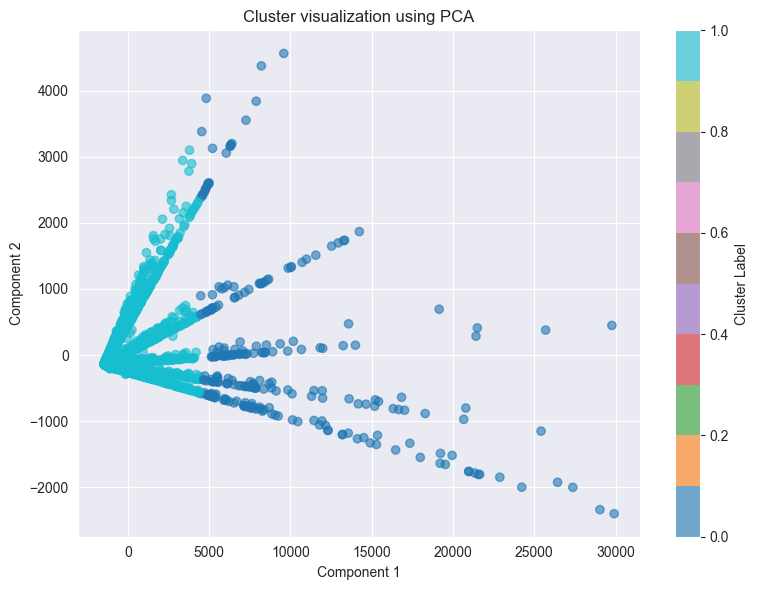

In [285]:
results = analyze_kmeans_clusters(df_scaled, labels, model=kmeans, visualize=True, method='pca')

In [286]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np

# 1. Standardizare (important pentru DBSCAN, altfel scalele diferite distrug clustering-ul)
X_scaled = df_scaled

# 2. DBSCAN (parametrii de ajustat: eps și min_samples)
db = DBSCAN(eps=0.5, min_samples=10).fit(X_scaled)
labels = db.labels_

# 3. Numar de clustere (label -1 = noise/outliers)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

# 4. Validare (doar daca avem minim 2 clustere)
if n_clusters > 1:
    silhouette = silhouette_score(X_scaled, labels)
    ch_index = calinski_harabasz_score(X_scaled, labels)
    db_index = davies_bouldin_score(X_scaled, labels)

    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Calinski-Harabasz Index: {ch_index:.2f}")
    print(f"Davies-Bouldin Index: {db_index:.4f}")
else:
    print("DBSCAN found less than 2 clusters, metrics not applicable.")


Estimated number of clusters: 0
Noise points: 5000
DBSCAN found less than 2 clusters, metrics not applicable.


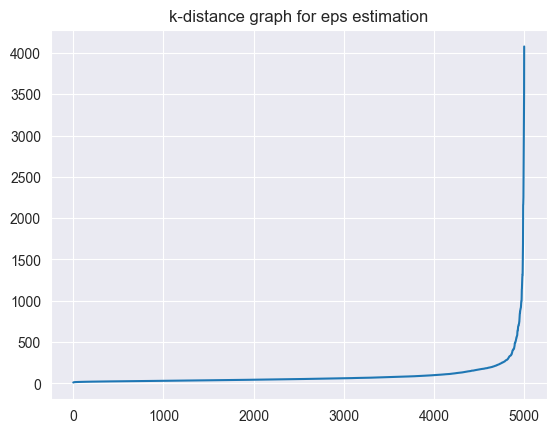

In [287]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# sortam distanțele la cel mai apropiat vecin
distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.title("k-distance graph for eps estimation")
plt.show()

In [288]:
db = DBSCAN(eps=2.5, min_samples=10).fit(X_scaled)
labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

Estimated clusters: 0
Noise points: 5000


In [289]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

labels = db.labels_
mask = labels != -1  # excludem noise-ul din scoruri

if len(set(labels[mask])) > 1:
    print("Silhouette:", silhouette_score(X_scaled[mask], labels[mask]))
    print("Calinski-Harabasz:", calinski_harabasz_score(X_scaled[mask], labels[mask]))
    print("Davies-Bouldin:", davies_bouldin_score(X_scaled[mask], labels[mask]))

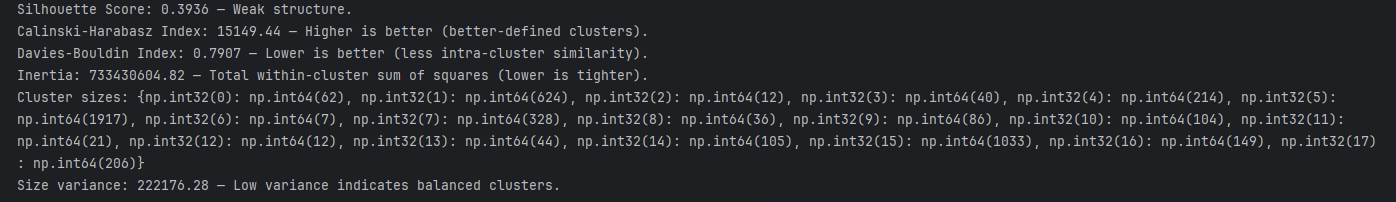

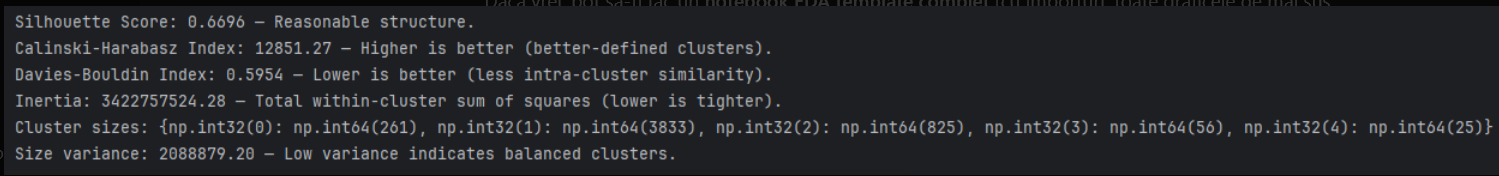

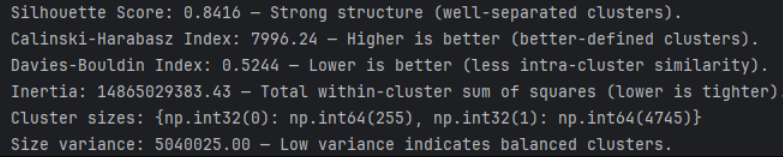